# Experiment 05 — Full CV Pipeline + Test Set Evaluation

This is the definitive evaluation notebook. It covers Tasks 3.3, 3.4, and 3.5.

**Methodology:**
1. Hold out 15% of data as a test set — it is never touched until the very end
2. For each model, sweep hyperparameters using 5-fold stratified CV on the remaining 85%
3. Select the best config per model (by CV ROC-AUC)
4. Re-train each best config on a fresh split and evaluate on the held-out test set

**Expected runtime:** 30–90 minutes on CPU depending on hardware. RF and GB are the slow ones.

In [ ]:
import sys, os
if 'google.colab' in str(get_ipython()):
    REPO = 'diabetes-uci-dataset'
    REPO_URL = 'https://github.com/byambaa0325/diabetes-uci-dataset.git'
    if not os.path.exists(REPO):
        os.system(f'git clone ${REPO_URL}')
    os.chdir(REPO)
    os.system('pip install -q -r requirements.txt')
else:
    root = os.path.abspath(os.path.join(os.getcwd(), '../../'))
    if root not in sys.path:
        sys.path.insert(0, root)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.pipeline import cross_validate_sweep, run_pipeline
from src.models.registry import MODEL_REGISTRY

sns.set_theme(style='whitegrid')

# ── Global config ────────────────────────────────────────────────────────────
TEST_RATIO  = 0.15   # held out from everything until the final evaluation
CV_SPLITS   = 5      # folds for hyperparameter selection
RANDOM_SEED = 42

BASE = {
    'wandb_project': 'applied-ai-coursework',
    'featurizer':    'full',
    'test_ratio':    TEST_RATIO,
}

print('Models available:', list(MODEL_REGISTRY.keys()))

Models available: ['mlp', 'logistic_regression', 'random_forest', 'gradient_boosting', 'svm', 'linear_svm']


---
## Hyperparameter grids

One grid per model. Each entry in `param_grid` is a set of overrides merged over `BASE`.
The parameter being swept is the only thing that changes between entries.

In [3]:
C_VALUES    = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
DEPTHS      = [2, 4, 6, 8, 12, None]   # None = unconstrained
GB_DEPTHS   = [2, 3, 4, 5, 6]
GB_LRS      = [0.01, 0.05, 0.1, 0.2]

SWEEPS = {
    'linear_svm': {
        'param_label': 'C',
        'param_values': C_VALUES,
        'grid': [
            {
                'name':         f'lsvm_C{c}',
                'model':        'linear_svm',
                'model_params': {'C': c, 'max_iter': 2000, 'class_weight': 'balanced'},
            }
            for c in C_VALUES
        ],
    },
    'logistic_regression': {
        'param_label': 'C',
        'param_values': C_VALUES,
        'grid': [
            {
                'name':         f'lr_C{c}',
                'model':        'logistic_regression',
                'model_params': {'C': c, 'max_iter': 1000, 'class_weight': 'balanced'},
            }
            for c in C_VALUES
        ],
    },
    'random_forest': {
        'param_label': 'max_depth',
        'param_values': DEPTHS,
        'grid': [
            {
                'name':         f'rf_depth{d}',
                'model':        'random_forest',
                'model_params': {
                    'n_estimators': 200, 'max_depth': d,
                    'class_weight': 'balanced', 'n_jobs': -1, 'random_state': RANDOM_SEED,
                },
            }
            for d in DEPTHS
        ],
    },
    'gradient_boosting': {
        'param_label': 'max_depth',
        'param_values': GB_DEPTHS,
        'grid': [
            {
                'name':         f'gb_depth{d}_lr{lr}',
                'model':        'gradient_boosting',
                'model_params': {
                    'n_estimators': 200, 'max_depth': d,
                    'learning_rate': lr, 'subsample': 0.8, 'random_state': RANDOM_SEED,
                },
                '_depth': d, '_lr': lr,
            }
            for d in GB_DEPTHS for lr in GB_LRS
        ],
    },
}

total_runs = sum(len(s['grid']) for s in SWEEPS.values()) * CV_SPLITS
print(f'Total training runs across all sweeps: {total_runs}')

Total training runs across all sweeps: 190


---
## CV sweeps

Running each model's grid with `cross_validate_sweep`. Features are built once per CV fold and shared across all configs in that fold, so featurization isn't repeated per hyperparameter value.

Results are stored in `cv_results` — a dict mapping model name → list of CV result dicts.

In [4]:
cv_results = {}

for model_name, sweep_cfg in SWEEPS.items():
    print('='*60)
    print(f'  {model_name}  —  {len(sweep_cfg["grid"])} configs × {CV_SPLITS} folds')
    print('='*60)

    cv_results[model_name] = cross_validate_sweep(
        base_config=BASE,
        param_grid=sweep_cfg['grid'],
        n_splits=CV_SPLITS,
        random_state=RANDOM_SEED,
    )

print('\nAll CV sweeps complete.')

  linear_svm  —  6 configs × 5 folds

[fold 1/5]


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\byamb\_netrc.


  -> lsvm_C0.001  

wandb: Currently logged in as: byambaa-bayarmandakh-25 (byambaa-bayarmandakh-25-ucl) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Run saved: E:\UCL-Workspaces\applied-ai-coursework\runs\2026-03-08_13-38-05_bc1263_lsvm_C0.001
  -> lsvm_C0.01  

...

Run saved: E:\UCL-Workspaces\applied-ai-coursework\runs\2026-03-08_14-33-14_c8e6e6_gb_depth6_lr0.05
  -> gb_depth6_lr0.1  

train_log_loss,▁
val_log_loss,▁
train_log_loss,0.54771
val_log_loss,0.63033


Run saved: E:\UCL-Workspaces\applied-ai-coursework\runs\2026-03-08_14-34-05_9c57cc_gb_depth6_lr0.1
  -> gb_depth6_lr0.2  

train_log_loss,▁
val_log_loss,▁
train_log_loss,0.49336
val_log_loss,0.64546


Run saved: E:\UCL-Workspaces\applied-ai-coursework\runs\2026-03-08_14-34-56_105085_gb_depth6_lr0.2

All CV sweeps complete.


---
## Task 3.4 — Performance vs hyperparameter

For each model: plot ROC-AUC, F1, and Recall(pos) as a function of the hyperparameter. Error bars show ± 1 std across folds.

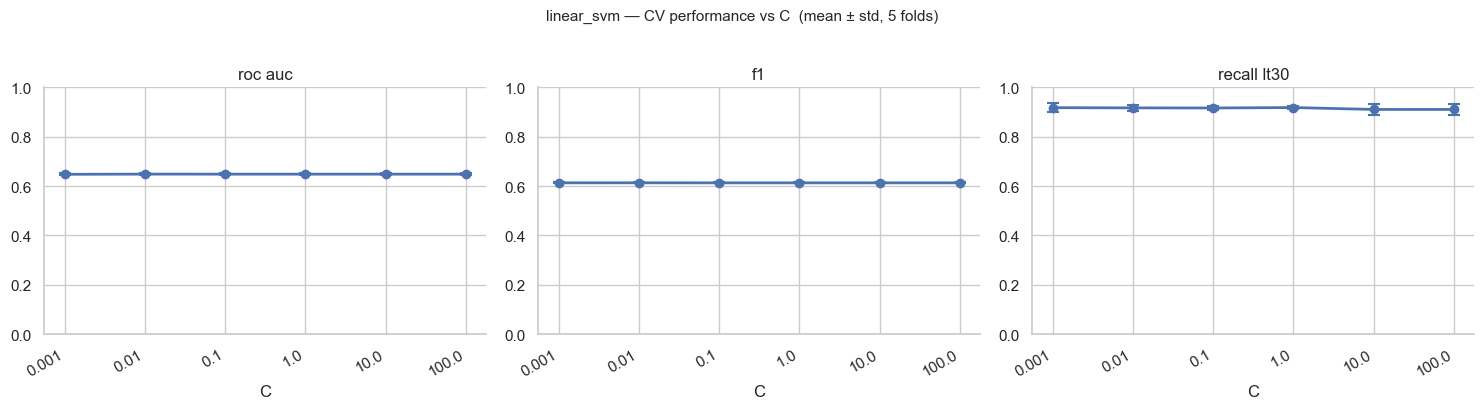

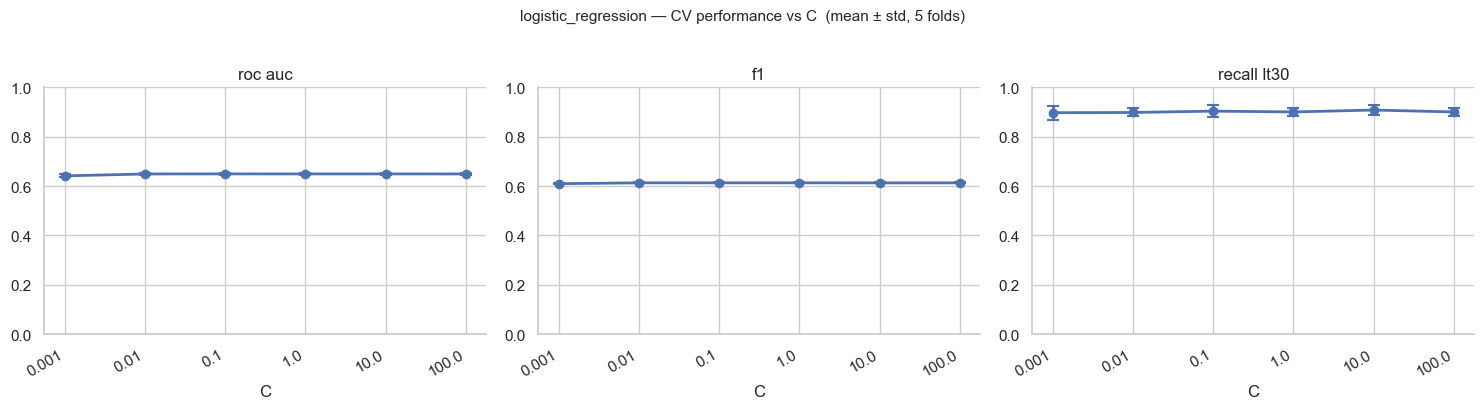

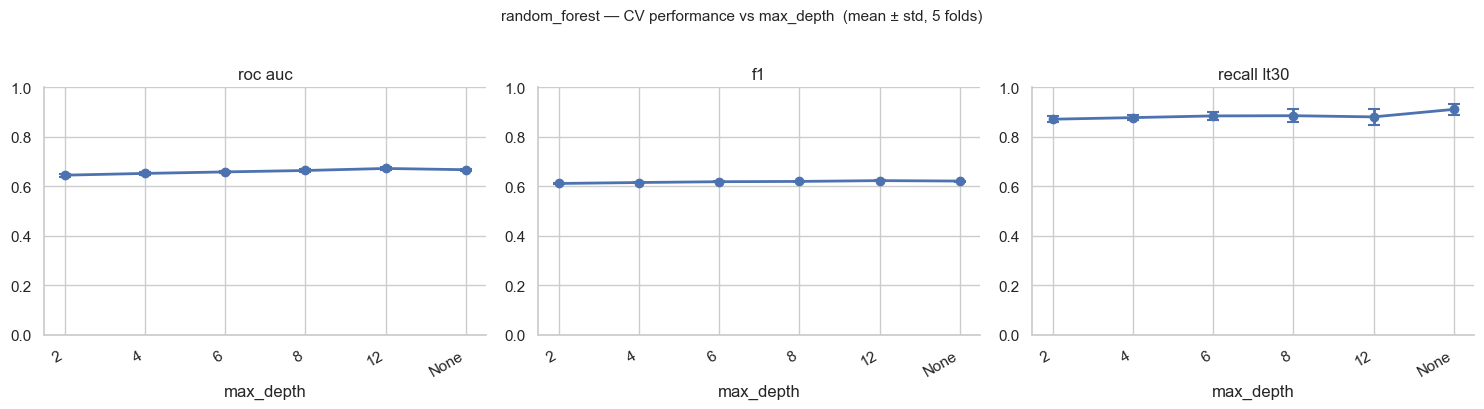

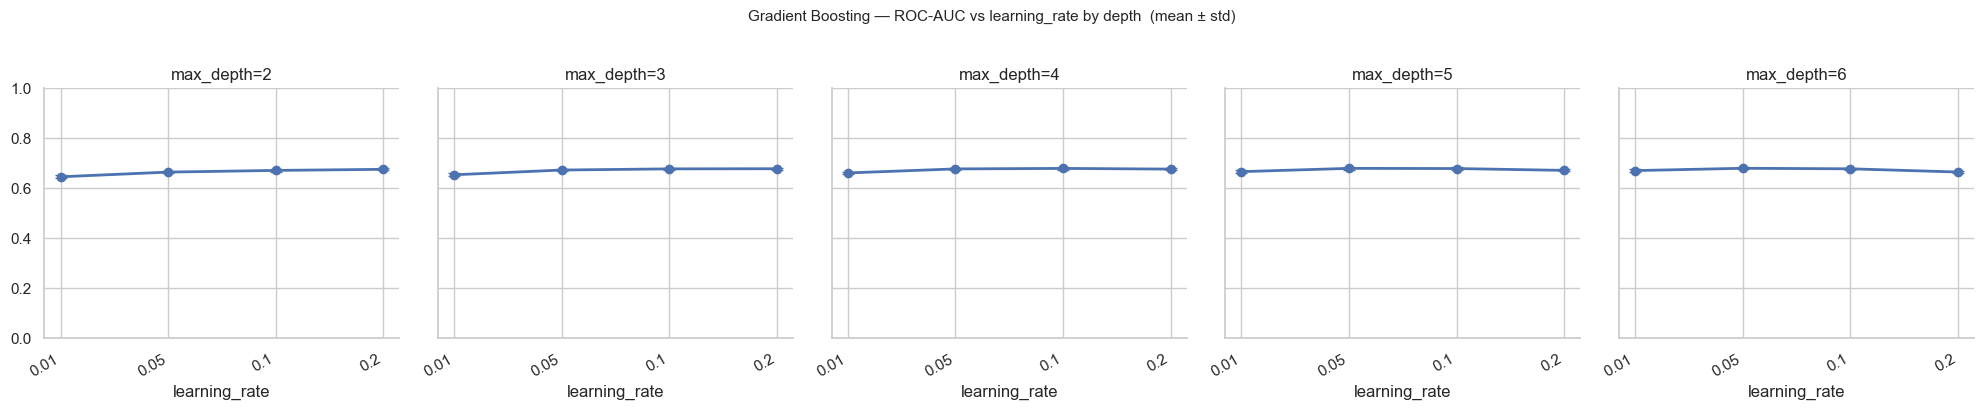

In [5]:
def plot_cv_sweep(model_name, sweep_cfg, results, metrics=('roc_auc', 'f1', 'recall_pos')):
    param_label  = sweep_cfg['param_label']
    param_values = sweep_cfg['param_values']
    x_labels     = [str(v) if v is not None else 'None' for v in param_values[:len(results)]]

    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 4))
    if len(metrics) == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):
        means = [r['summary'].get(f'{metric}_mean', 0) for r in results]
        stds  = [r['summary'].get(f'{metric}_std',  0) for r in results]
        ax.errorbar(range(len(means)), means, yerr=stds,
                    marker='o', linewidth=2, capsize=4, capthick=1.5)
        ax.set_xticks(range(len(x_labels)))
        ax.set_xticklabels(x_labels, rotation=30, ha='right')
        ax.set_xlabel(param_label)
        ax.set_title(metric.replace('_', ' '))
        ax.set_ylim(0, 1)
        sns.despine(ax=ax)

    fig.suptitle(f'{model_name} — CV performance vs {param_label}  (mean ± std, {CV_SPLITS} folds)',
                 fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig(f'../../outputs/figures/{model_name}_sweep.png', bbox_inches='tight', dpi=120)
    plt.show()


for model_name, sweep_cfg in SWEEPS.items():
    results = cv_results[model_name]
    # Gradient boosting has a 2D grid — aggregate by max_depth for plotting
    if model_name == 'gradient_boosting':
        gb_depths = sorted(set(cfg['_depth'] for cfg in sweep_cfg['grid']))
        gb_lrs    = sorted(set(cfg['_lr']    for cfg in sweep_cfg['grid']))
        fig, axes = plt.subplots(1, len(gb_depths), figsize=(4 * len(gb_depths), 4), sharey=True)
        for ax, d in zip(axes, gb_depths):
            depth_results = [
                r for cfg, r in zip(sweep_cfg['grid'], results) if cfg['_depth'] == d
            ]
            means = [r['summary'].get('roc_auc_mean', 0) for r in depth_results]
            stds  = [r['summary'].get('roc_auc_std',  0) for r in depth_results]
            ax.errorbar(range(len(means)), means, yerr=stds, marker='o', linewidth=2, capsize=4)
            ax.set_xticks(range(len(gb_lrs)))
            ax.set_xticklabels([str(lr) for lr in gb_lrs], rotation=30, ha='right')
            ax.set_xlabel('learning_rate')
            ax.set_title(f'max_depth={d}')
            ax.set_ylim(0, 1)
            sns.despine(ax=ax)
        fig.suptitle('Gradient Boosting — ROC-AUC vs learning_rate by depth  (mean ± std)',
                     fontsize=11, y=1.02)
        plt.tight_layout()
        plt.savefig('../../outputs/figures/gradient_boosting_sweep.png', bbox_inches='tight', dpi=120)
        plt.show()
    else:
        plot_cv_sweep(model_name, sweep_cfg, results)

---
## Task 3.5 (part 1) — CV performance table

Mean ± std across folds for every hyperparameter value. Best config per model highlighted.

In [6]:
rows = []
best_configs = {}   # model_name → best param_grid entry

for model_name, sweep_cfg in SWEEPS.items():
    results = cv_results[model_name]
    for cfg, r in zip(sweep_cfg['grid'], results):
        s = r['summary']
        rows.append({
            'model':        model_name,
            'config':       cfg['name'],
            'ROC-AUC':      f"{s.get('roc_auc_mean', 0):.4f} ± {s.get('roc_auc_std', 0):.4f}",
            'F1':           f"{s.get('f1_mean', 0):.4f} ± {s.get('f1_std', 0):.4f}",
            'Recall':       f"{s.get('recall_mean', 0):.4f} ± {s.get('recall_std', 0):.4f}",
            'Recall(pos)':  f"{s.get('recall_pos_mean', 0):.4f} ± {s.get('recall_pos_std', 0):.4f}",
            '_auc':         s.get('roc_auc_mean', 0),
        })

    # Best config = highest CV ROC-AUC
    best_idx = max(range(len(results)), key=lambda i: results[i]['summary'].get('roc_auc_mean', 0))
    best_configs[model_name] = sweep_cfg['grid'][best_idx]
    print(f'{model_name}: best config = {sweep_cfg["grid"][best_idx]["name"]}')

cv_df = pd.DataFrame(rows).drop(columns=['_auc'])
display(cv_df.set_index(['model', 'config']))

linear_svm: best config = lsvm_C0.01
logistic_regression: best config = lr_C0.1
random_forest: best config = rf_depth12
gradient_boosting: best config = gb_depth6_lr0.05


ROC-AUC               F1  \
model               config                                               
linear_svm          lsvm_C0.001       0.6478 ± 0.0048  0.6132 ± 0.0018   
                    lsvm_C0.01        0.6486 ± 0.0043  0.6134 ± 0.0017   
                    lsvm_C0.1         0.6484 ± 0.0042  0.6131 ± 0.0017   
                    lsvm_C1.0         0.6484 ± 0.0042  0.6131 ± 0.0017   
                    lsvm_C10.0        0.6484 ± 0.0042  0.6131 ± 0.0017   
                    lsvm_C100.0       0.6484 ± 0.0042  0.6131 ± 0.0017   
logistic_regression lr_C0.001         0.6414 ± 0.0056  0.6097 ± 0.0021   
                    lr_C0.01          0.6491 ± 0.0049  0.6132 ± 0.0018   
                    lr_C0.1           0.6495 ± 0.0045  0.6133 ± 0.0017   
                    lr_C1.0           0.6494 ± 0.0044  0.6133 ± 0.0018   
                    lr_C10.0          0.6494 ± 0.0043  0.6131 ± 0.0016   
                    lr_C100.0         0.6492 ± 0.0043  0.6131 ± 0.0016   
random_forest       rf_depth2         0.6451 ± 0.0055  0.6115 ± 0.0014   
                    rf_depth4         0.6522 ± 0.0051  0.6154 ± 0.0023   
                    rf_depth6         0.6583 ± 0.0053  0.6187 ± 0.0024   
                    rf_depth8         0.6641 ± 0.0047  0.6198 ± 0.0028   
                    rf_depth12        0.6723 ± 0.0056  0.6231 ± 0.0026   
                    rf_depthNone      0.6672 ± 0.0047  0.6213 ± 0.0020   
gradient_boosting   gb_depth2_lr0.01  0.6436 ± 0.0054  0.6132 ± 0.0013   
                    gb_depth2_lr0.05  0.6624 ± 0.0049  0.6195 ± 0.0024   
                    gb_depth2_lr0.1   0.6691 ± 0.0046  0.6219 ± 0.0025   
                    gb_depth2_lr0.2   0.6735 ± 0.0046  0.6238 ± 0.0022   
                    gb_depth3_lr0.01  0.6517 ± 0.0051  0.6163 ± 0.0012   
                    gb_depth3_lr0.05  0.6706 ± 0.0049  0.6224 ± 0.0020   
                    gb_depth3_lr0.1   0.6753 ± 0.0046  0.6247 ± 0.0015   
                    gb_depth3_lr0.2   0.6759 ± 0.0032  0.6250 ± 0.0018   
                    gb_depth4_lr0.01  0.6590 ± 0.0052  0.6184 ± 0.0017   
                    gb_depth4_lr0.05  0.6751 ± 0.0050  0.6243 ± 0.0026   
                    gb_depth4_lr0.1   0.6771 ± 0.0045  0.6252 ± 0.0021   
                    gb_depth4_lr0.2   0.6744 ± 0.0045  0.6241 ± 0.0030   
                    gb_depth5_lr0.01  0.6642 ± 0.0052  0.6203 ± 0.0026   
                    gb_depth5_lr0.05  0.6773 ± 0.0053  0.6257 ± 0.0026   
                    gb_depth5_lr0.1   0.6765 ± 0.0043  0.6254 ± 0.0028   
                    gb_depth5_lr0.2   0.6692 ± 0.0036  0.6222 ± 0.0034   
                    gb_depth6_lr0.01  0.6684 ± 0.0051  0.6215 ± 0.0025   
                    gb_depth6_lr0.05  0.6776 ± 0.0048  0.6257 ± 0.0026   
                    gb_depth6_lr0.1   0.6755 ± 0.0039  0.6244 ± 0.0018   
                    gb_depth6_lr0.2   0.6627 ± 0.0026  0.6207 ± 0.0012   

                                               Recall      Recall(pos)  
model               config                                              
linear_svm          lsvm_C0.001       0.5649 ± 0.0089  0.9181 ± 0.0175  
                    lsvm_C0.01        0.5654 ± 0.0069  0.9172 ± 0.0136  
                    lsvm_C0.1         0.5652 ± 0.0053  0.9168 ± 0.0073  
                    lsvm_C1.0         0.5646 ± 0.0044  0.9185 ± 0.0052  
                    lsvm_C10.0        0.5672 ± 0.0058  0.9109 ± 0.0231  
                    lsvm_C100.0       0.5672 ± 0.0058  0.9109 ± 0.0231  
logistic_regression lr_C0.001         0.5654 ± 0.0115  0.8977 ± 0.0276  
                    lr_C0.01          0.5712 ± 0.0066  0.8986 ± 0.0162  
                    lr_C0.1           0.5697 ± 0.0079  0.9040 ± 0.0248  
                    lr_C1.0           0.5708 ± 0.0042  0.9007 ± 0.0144  
                    lr_C10.0          0.5678 ± 0.0049  0.9085 ± 0.0202  
                    lr_C100.0         0.5705 ± 0.0057  0.9007 ± 0.0158  
random_forest       rf_depth2         0.5773 ± 0.0034  0.8716 ±

---
## Task 3.5 (part 2) — Test set evaluation

Best config per model is now trained on the 85% non-test data and evaluated on the held-out 15% test set. This is the first and only time the test set is used.


[linear_svm] evaluating best config on test set...


Run saved: E:\UCL-Workspaces\applied-ai-coursework\runs\2026-03-08_14-35-53_8a940b_lsvm_C0.01


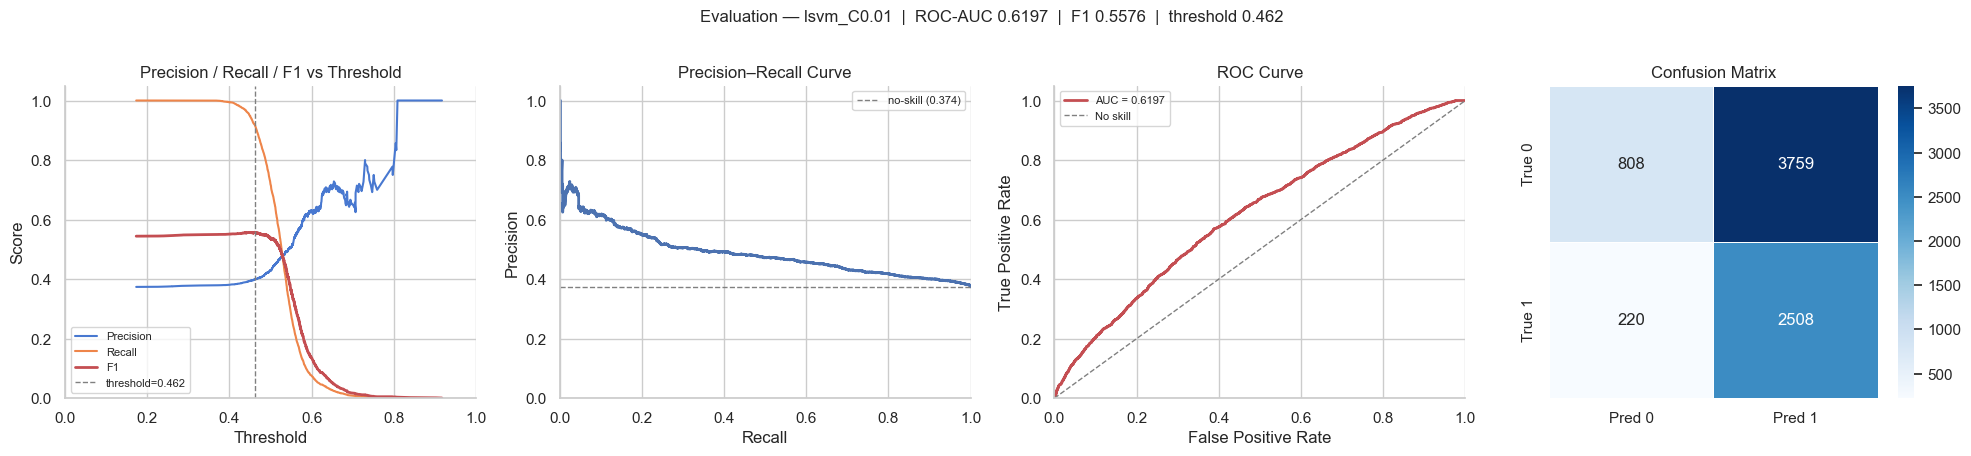

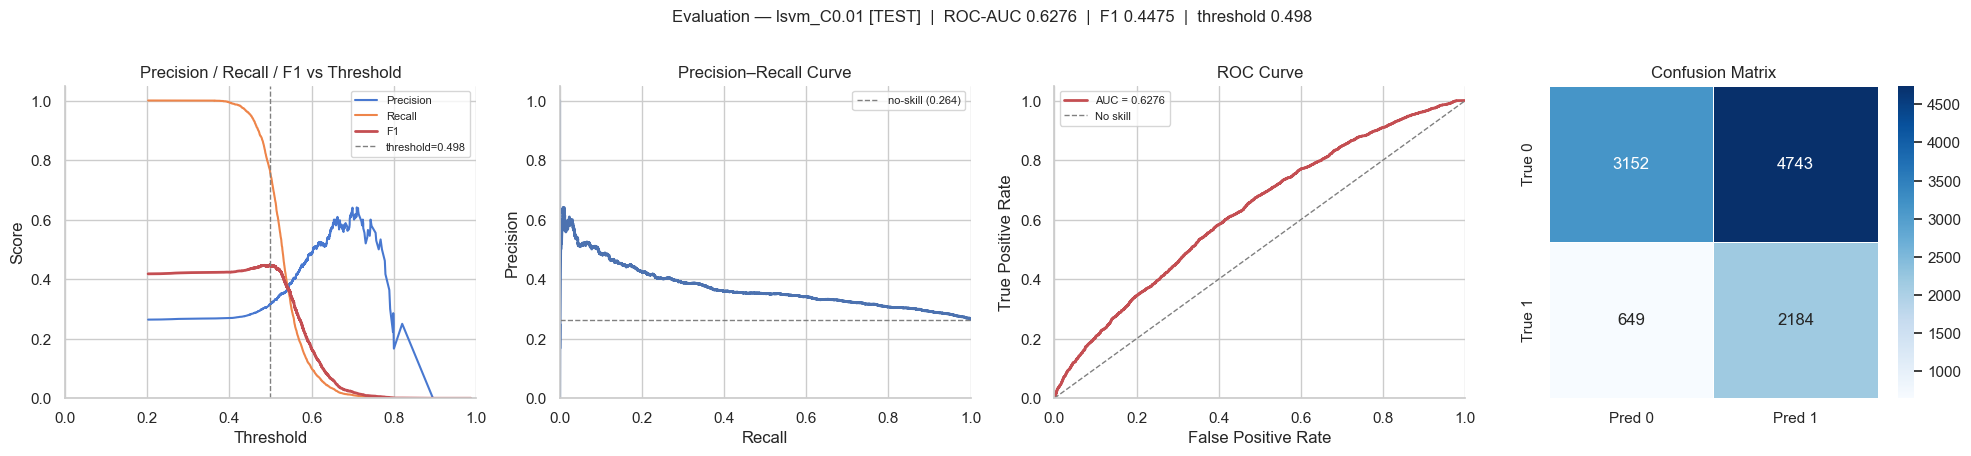

  [val]  ROC-AUC=0.6197  F1=0.5576  Recall=0.5481  Recall(pos)=0.9194  (5.7s)
  [test] ROC-AUC=0.6276  F1=0.4475  Recall=0.5851  Recall(pos)=0.7709

[logistic_regression] evaluating best config on test set...


e:\UCL-Workspaces\applied-ai-coursework\.conda\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


train_log_loss,▁
val_log_loss,▁
train_log_loss,0.65008
val_log_loss,0.68538


Run saved: E:\UCL-Workspaces\applied-ai-coursework\runs\2026-03-08_14-36-01_7fdd30_lr_C0.1


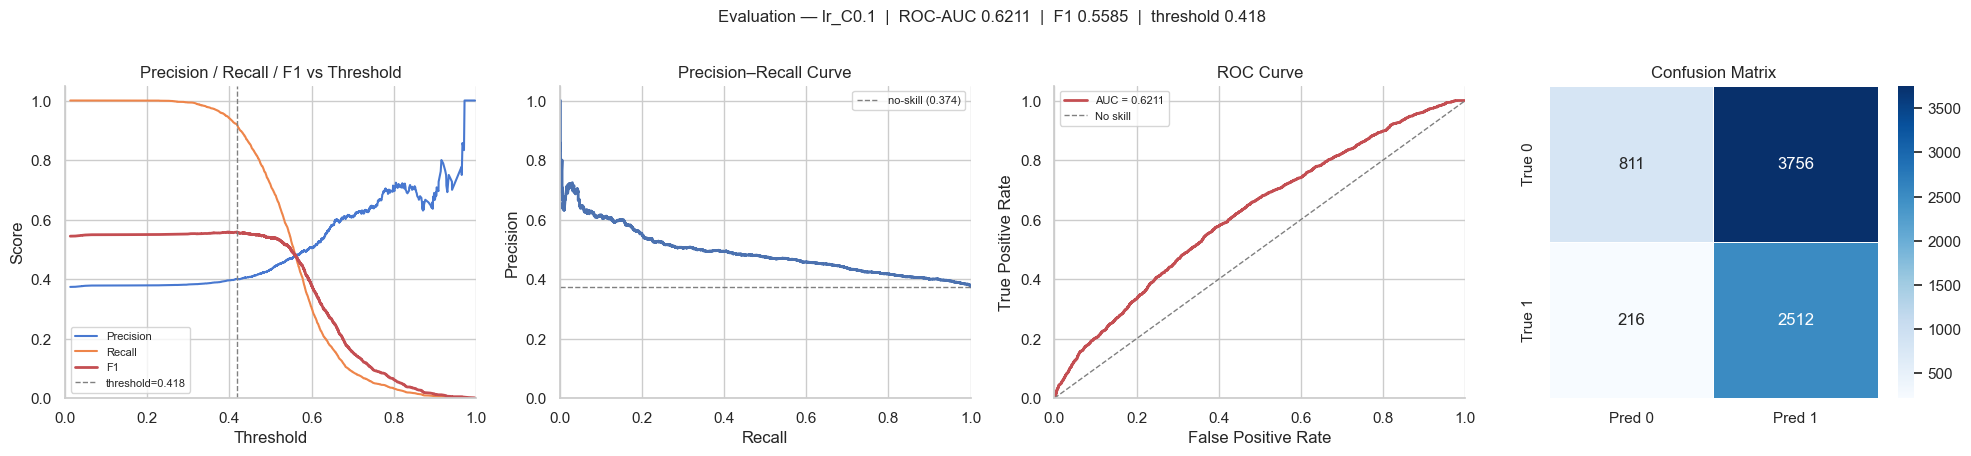

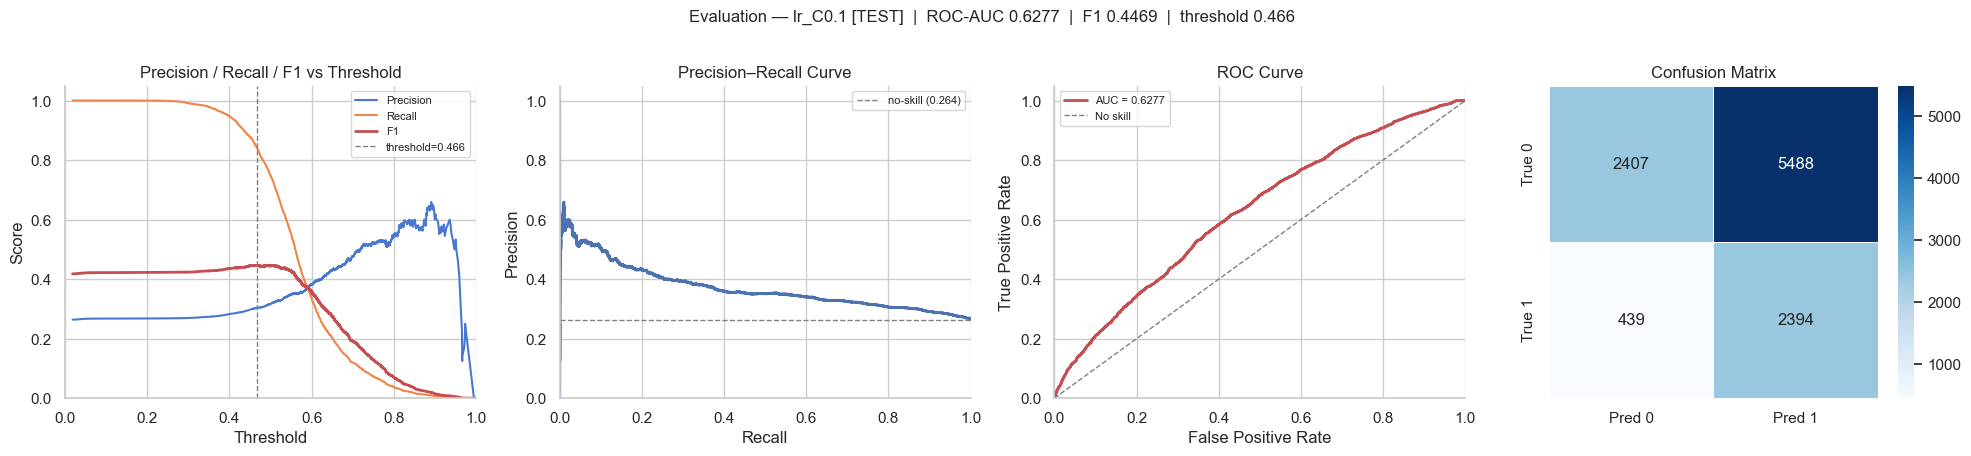

  [val]  ROC-AUC=0.6211  F1=0.5585  Recall=0.5492  Recall(pos)=0.9208  (15.2s)
  [test] ROC-AUC=0.6277  F1=0.4469  Recall=0.5750  Recall(pos)=0.8450

[random_forest] evaluating best config on test set...


train_log_loss,▁
val_log_loss,▁
train_log_loss,0.60223
val_log_loss,0.67875


Run saved: E:\UCL-Workspaces\applied-ai-coursework\runs\2026-03-08_14-36-18_e4760b_rf_depth12


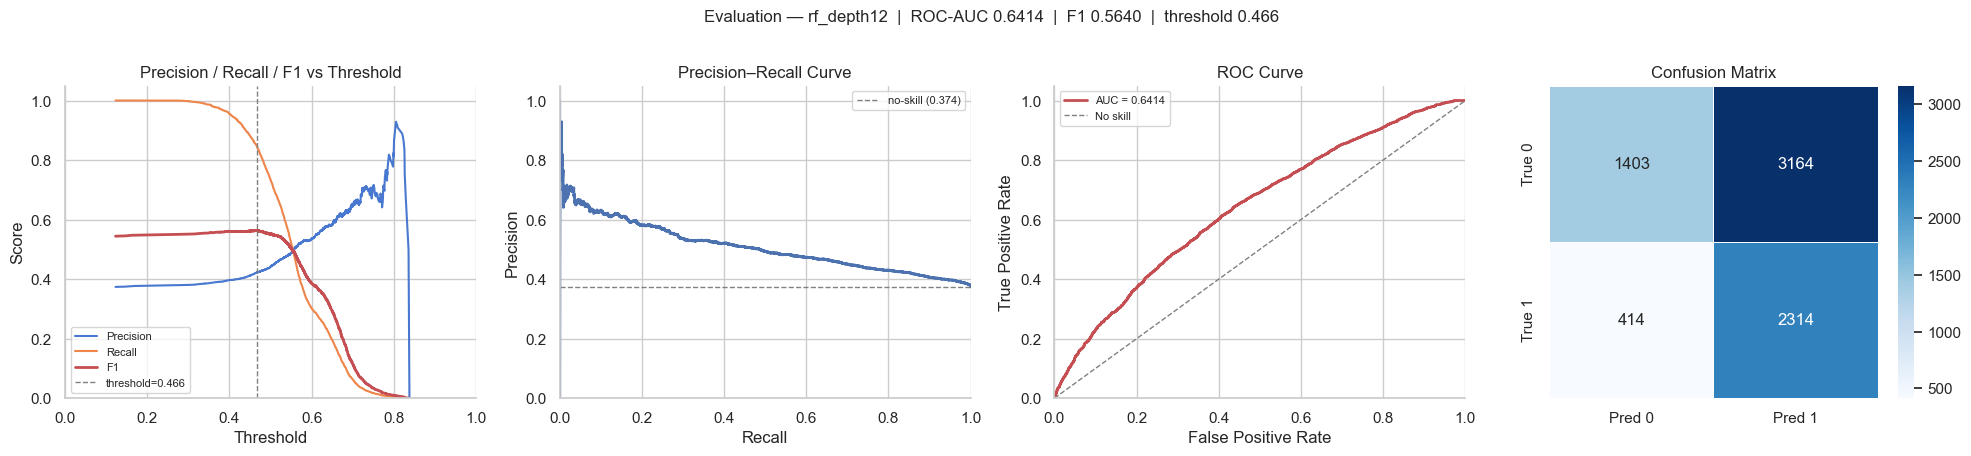

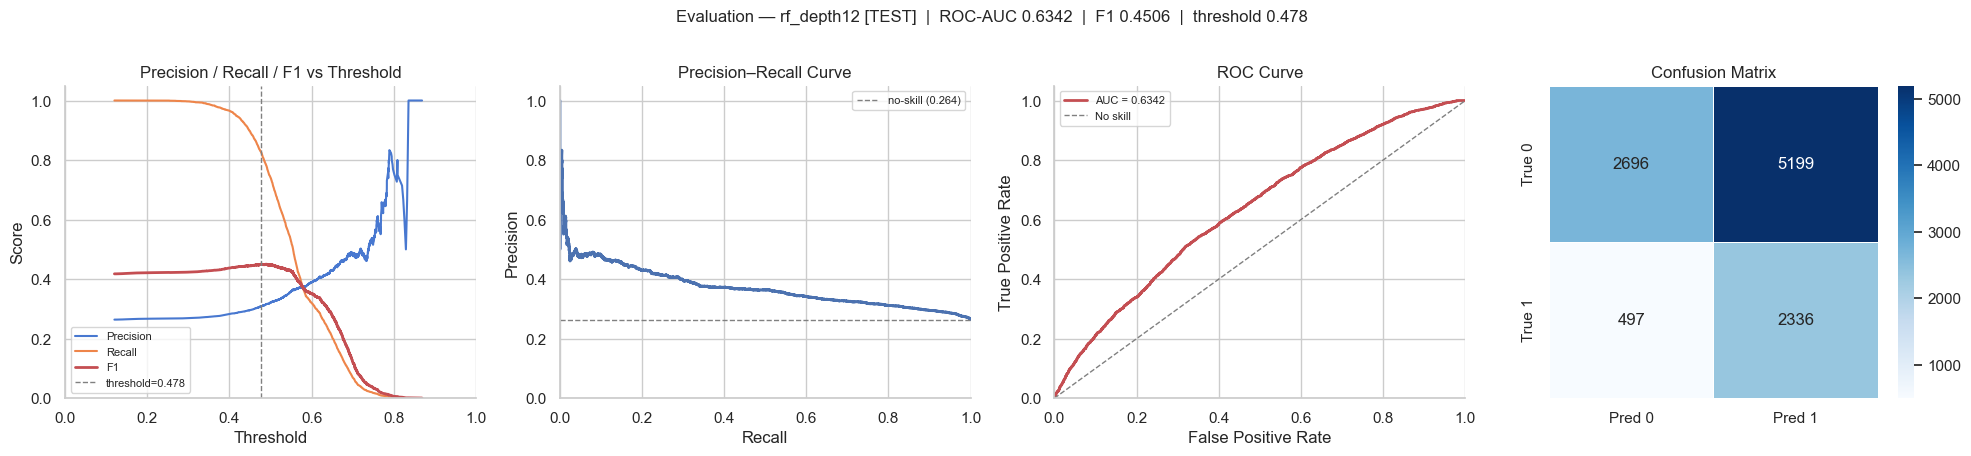

  [val]  ROC-AUC=0.6414  F1=0.5640  Recall=0.5777  Recall(pos)=0.8482  (6.5s)
  [test] ROC-AUC=0.6342  F1=0.4506  Recall=0.5830  Recall(pos)=0.8246

[gradient_boosting] evaluating best config on test set...


train_log_loss,▁
val_log_loss,▁
train_log_loss,0.58529
val_log_loss,0.6499


Run saved: E:\UCL-Workspaces\applied-ai-coursework\runs\2026-03-08_14-36-27_3edfd5_gb_depth6_lr0.05


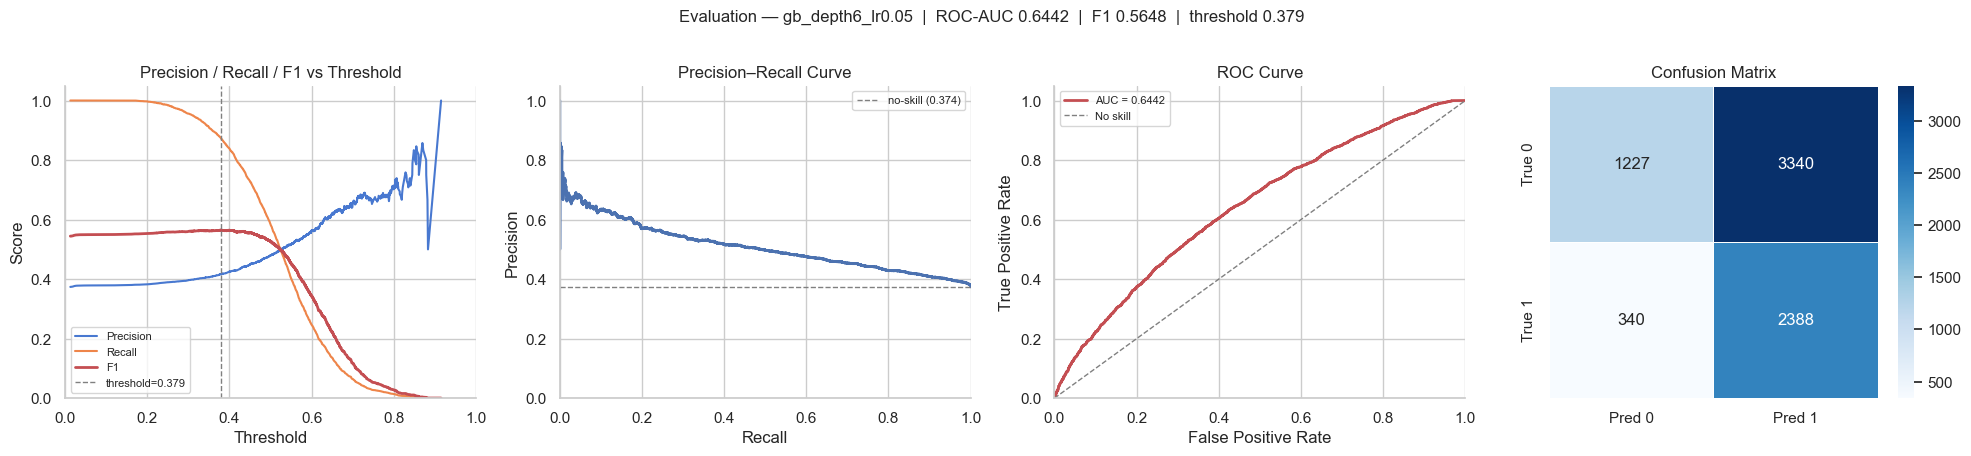

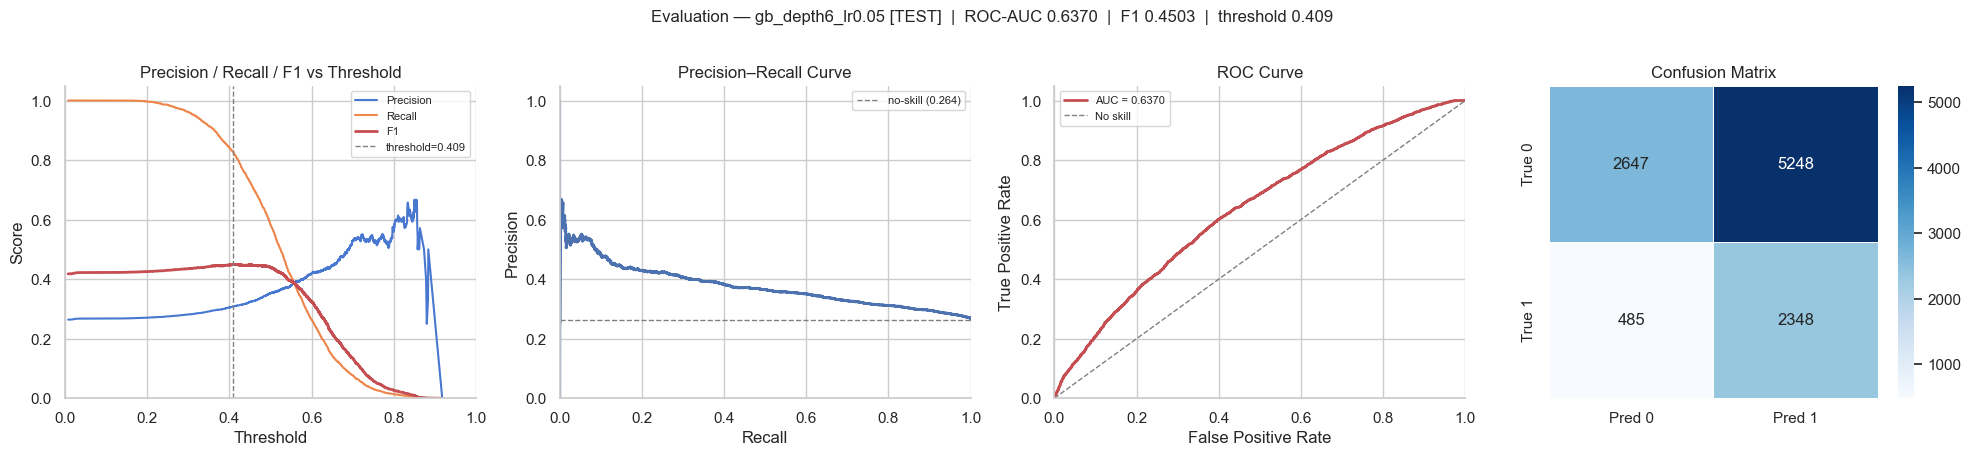

  [val]  ROC-AUC=0.6442  F1=0.5648  Recall=0.5720  Recall(pos)=0.8754  (59.5s)
  [test] ROC-AUC=0.6370  F1=0.4503  Recall=0.5820  Recall(pos)=0.8288

Test evaluation complete.


In [7]:
test_results = {}

for model_name, best_cfg in best_configs.items():
    print(f'\n[{model_name}] evaluating best config on test set...')
    cfg = {
        **BASE,
        **best_cfg,
        'split_ratio': 0.88,  # of the 85% non-test — maximise training data
        'plot': True,
    }
    # Remove internal keys not meant for the pipeline
    cfg.pop('_depth', None)
    cfg.pop('_lr', None)

    result = run_pipeline(cfg)
    test_results[model_name] = result

print('\nTest evaluation complete.')

---
## Final comparison table

Best config per model: CV val performance (mean ± std) alongside held-out test performance.

In [8]:
rows = []
for model_name, result in test_results.items():
    best_cfg = best_configs[model_name]
    best_cv  = cv_results[model_name][
        SWEEPS[model_name]['grid'].index(best_cfg)
    ]['summary']

    tm = result.test_metrics or {}
    rows.append({
        'model':                model_name,
        'best_config':          best_cfg['name'],
        'CV ROC-AUC':           f"{best_cv.get('roc_auc_mean',0):.4f} ± {best_cv.get('roc_auc_std',0):.4f}",
        'CV F1':                f"{best_cv.get('f1_mean',0):.4f} ± {best_cv.get('f1_std',0):.4f}",
        'CV Recall(pos)':       f"{best_cv.get('recall_pos_mean',0):.4f} ± {best_cv.get('recall_pos_std',0):.4f}",
        'Test ROC-AUC':         round(tm.get('roc_auc', 0), 4),
        'Test F1':              round(tm.get('f1', 0), 4),
        'Test Recall(pos)':     round(tm.get('recall_pos', 0), 4),
        'Test Threshold':       round(tm.get('threshold', 0), 3),
        'Time(s)':              round(result.elapsed_s, 1),
    })

final_df = pd.DataFrame(rows).set_index('model')
display(final_df)

# Save for report
final_df.to_csv('../../outputs/tables/final_model_comparison.csv')

,best_config,CV ROC-AUC,CV F1,CV Recall(<30),Test ROC-AUC,Test F1,Test Recall(<30),Test Threshold,Time(s)
model,,,,,,,,,
linear_svm,lsvm_C0.01,0.6486 ± 0.0043,0.6134 ± 0.0017,0.9172 ± 0.0136,0.6276,0.4475,0.7709,0.498,5.7
logistic_regression,lr_C0.1,0.6495 ± 0.0045,0.6133 ± 0.0017,0.9040 ± 0.0248,0.6277,0.4469,0.8450,0.466,15.2
random_forest,rf_depth12,0.6723 ± 0.0056,0.6231 ± 0.0026,0.8810 ± 0.0328,0.6342,0.4506,0.8246,0.478,6.5
gradient_boosting,gb_depth6_lr0.05,0.6776 ± 0.0048,0.6257 ± 0.0026,0.8799 ± 0.0266,0.6370,0.4503,0.8288,0.409,59.5


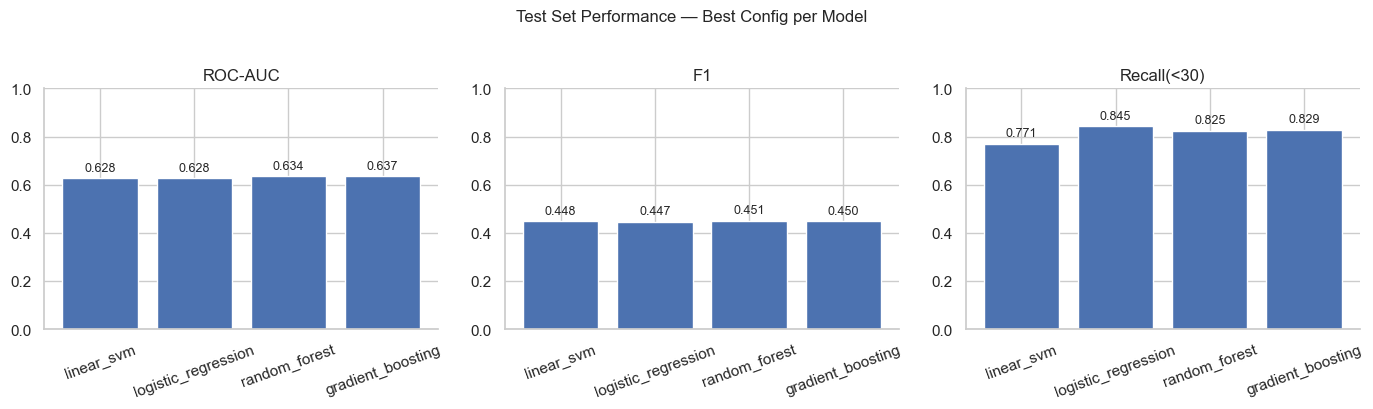

In [9]:
# Visual comparison of test performance
test_metrics_list = ['Test ROC-AUC', 'Test F1', 'Test Recall(pos)']
plot_df = final_df[test_metrics_list].copy()
plot_df.columns = ['ROC-AUC', 'F1', 'Recall(pos)']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, plot_df.columns):
    bars = ax.bar(plot_df.index, plot_df[col], color='#4C72B0', edgecolor='white')
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
    ax.set_title(col)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=20)
    sns.despine(ax=ax)

fig.suptitle('Test Set Performance — Best Config per Model', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../../outputs/figures/final_model_comparison.png', bbox_inches='tight', dpi=120)
plt.show()